U ovoj svesci implementiran je pristup klasifikaciji bolesti lista paradajza primenom transfer learning tehnike i unapred istreniranog `ResNet18` modela. Transfer learning omogućava iskorišćavanje znanja stečenog tokom treniranja modela na velikim skupovima podataka, čime se ubrzava proces učenja i poboljšavaju performanse modela, naročito kada raspoloživi skup podataka nije dovoljno veliki za treniranje duboke neuronske mreže od početka.

Koristićemo isti skup podataka i podelu kao i u prethodnim sveskama.

#### UČITAVANJE PAKETA

In [51]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

#### PUTANJE, PARAMETRI, DEVICE

In [52]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

# Ovaj kod nam služi samo za proveru
#print("Train dir:", train_dir.resolve())
#print("Test dir:", test_dir.resolve())

print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

# ResNet18 je pretreniran na ImageNet skupu, pa je prirodno koristiti 224x224.
# Ako je treniranje presporo na CPU, može se probati IMG_SIZE = 128, ali je 224 standardnije za transfer learning.
IMG_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42

best_model_path = Path("transfer_learning_resnet18_best.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train exists: True
Test exists: True
Device: cpu


In [53]:
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#### TRANSFORMACIJE SLIKA

Koristimo iste ImageNet vrednosti za normalizaciju kao u prethodnim sveskama zato što se ResNet18 trenira nad ImageNet slikama sa baš ovom normalizacijom.

In [54]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() može da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogućava čitanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraća običnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### UČITAVANJE SKUPA PODATAKA

Da bismo imali augmentacije samo na treningu, pravimo dva `ImageFolder` objekta nad istim `train` folderom:
- jedan sa `train_transform`;
- drugi sa `eval_transform`.

Zatim koristimo iste indekse za train/validation podelu. Dakle, imamo dva `ImageFolder` objekta nad istim `train_dir`, ali sa različitim transformacijama.

In [55]:
full_train_dataset_augmented = datasets.ImageFolder(
    root=str(train_dir),
    transform=train_transform,
    loader=pil_loader_safe
)

full_train_dataset_eval = datasets.ImageFolder(
    root=str(train_dir),
    transform=eval_transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=eval_transform,
    loader=pil_loader_safe
)

class_names = full_train_dataset_augmented.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(full_train_dataset_augmented))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


#### TRAIN/VALIDATION PODELA

In [56]:
val_size = int(len(full_train_dataset_augmented) * VALIDATION_SPLIT)
train_size = len(full_train_dataset_augmented) - val_size

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(len(full_train_dataset_augmented), generator=generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(full_train_dataset_augmented, train_indices)
val_dataset = torch.utils.data.Subset(full_train_dataset_eval, val_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 2000
Test size: 1000


#### DATALOADER-I

In [57]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### DEFINICIJA TRANSFER LEARNING MODELA

Funkcija `create_resnet18_transfer_model` kreira model zasnovan na unapred istreniranoj arhitekturi `ResNet18`, pri čemu se koriste težine naučene na skupu podataka `ImageNet`. Na početku se učitava prethodno trenirani model, pri čemu je obezbeđena kompatibilnost sa različitim verzijama biblioteke `torchvision`.

Kako bi se iskoristilo prethodno naučeno znanje modela, svi postojeći slojevi se najpre zamrzavaju postavljanjem atributa `requires_grad=False`, čime se njihove težine ne menjaju tokom treniranja. Zatim se odmrzava poslednji rezidualni blok (`layer4`), čime se modelu omogućava da prilagodi najviše nivoe izdvojenih karakteristika konkretnom problemu klasifikacije bolesti lista paradajza.

Na kraju se originalni klasifikacioni sloj zamenjuje novim, koji se sastoji od `Dropout` sloja radi smanjenja preprilagođavanja i potpuno povezanog (`Linear`) sloja čiji broj izlaznih neurona odgovara broju klasa u posmatranom skupu podataka. Dobijeni model je spreman za dalje treniranje primenom transfer learning pristupa.

In [58]:
# frozen transfer learning nam nije dao mnogo dobre rezultate jer ImageNet reprezentacije nisu dovoljno specifične za bolesti biljaka, 
# zbog čega smo promenile ovu funkciju

def create_resnet18_transfer_model(num_classes):
    """
    Kreira ResNet18 transfer learning model.
    Funkcija radi i sa novijim i sa starijim verzijama torchvision biblioteke.
    """
    
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except AttributeError:
        model = models.resnet18(pretrained=True)

    # Zamrzavamo sve prethodno naučene slojeve
    for param in model.parameters():
        param.requires_grad = False

    # Odmrzavamo poslednji residual blok
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Novi klasifikator
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

model = create_resnet18_transfer_model(num_classes).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

#### TRENIRANJE MODELA

In [59]:
EPOCHS = 10  # probale smo 25 i 20, ali su se već sa 10 epoha ostvarili odlični rezultati tkd smo smanjile broj
LEARNING_RATE = 0.0001 # pokušale smo i sa 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),   # ažurira samo slojeve koji se stvarno treniraju
    lr=LEARNING_RATE
)

metrics = {
    "train_loss": [],
    "train_accuracy": [],
    "train_steps": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_steps": []
}

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0
best_val_acc = 0.0

training_step = 0

for epoch in range(EPOCHS):
    model.train()
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        predicted = torch.argmax(outputs, dim=1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / labels.size(0)
        
        metrics["train_loss"].append(loss.item())
        metrics["train_accuracy"].append(accuracy)
        metrics["train_steps"].append(training_step)
        training_step += 1
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_samples = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            predicted = torch.argmax(outputs, dim=1)
            
            val_loss += loss.item() * labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_samples += labels.size(0)
    
        avg_val_loss = val_loss / val_samples
        avg_val_accuracy = val_correct / val_samples
        
        metrics["val_loss"].append(avg_val_loss)
        metrics["val_accuracy"].append(avg_val_accuracy)
        metrics["val_steps"].append(training_step)
    
    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Val loss: {avg_val_loss:.4f}, "
        f"Val acc: {avg_val_accuracy:.4f}"
    )
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_acc = avg_val_accuracy
        best_epoch = epoch + 1
        best_model_state = model.state_dict().copy()
        print("  -> Novi najbolji model")

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), best_model_path)

print("\nTreniranje završeno.")
print(f"Najbolji model je iz epohe {best_epoch}")
print(f"Najbolji val_loss: {best_val_loss:.4f}")
print(f"Val_acc tog modela: {best_val_acc:.4f}")
print(f"Najbolji model je sačuvan u: {best_model_path}")

Epoch [1/10] Val loss: 0.1517, Val acc: 0.9520
  -> Novi najbolji model
Epoch [2/10] Val loss: 0.0881, Val acc: 0.9710
  -> Novi najbolji model
Epoch [3/10] Val loss: 0.0690, Val acc: 0.9760
  -> Novi najbolji model
Epoch [4/10] Val loss: 0.0638, Val acc: 0.9780
  -> Novi najbolji model
Epoch [5/10] Val loss: 0.0575, Val acc: 0.9830
  -> Novi najbolji model
Epoch [6/10] Val loss: 0.0474, Val acc: 0.9850
  -> Novi najbolji model
Epoch [7/10] Val loss: 0.0452, Val acc: 0.9850
  -> Novi najbolji model
Epoch [8/10] Val loss: 0.0383, Val acc: 0.9900
  -> Novi najbolji model
Epoch [9/10] Val loss: 0.0466, Val acc: 0.9860
Epoch [10/10] Val loss: 0.0429, Val acc: 0.9855

Treniranje završeno.
Najbolji model je iz epohe 8
Najbolji val_loss: 0.0383
Val_acc tog modela: 0.9900
Najbolji model je sačuvan u: transfer_learning_resnet18_best.pth


#### GRAFICI TRENINGA

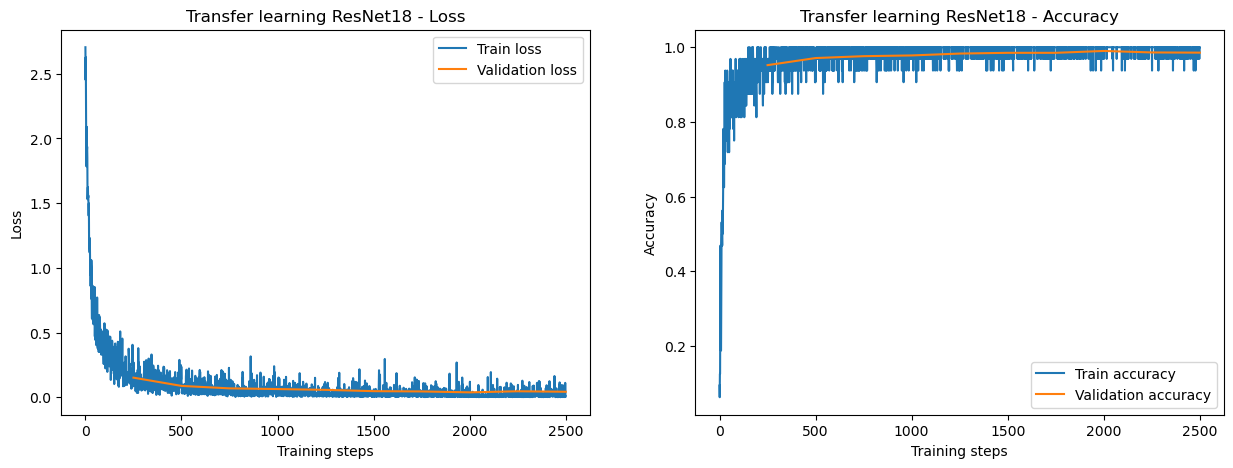

In [60]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(metrics["train_steps"], metrics["train_loss"], label="Train loss")
plt.plot(metrics["val_steps"], metrics["val_loss"], label="Validation loss")
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Transfer learning ResNet18 - Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(metrics["train_steps"], metrics["train_accuracy"], label="Train accuracy")
plt.plot(metrics["val_steps"], metrics["val_accuracy"], label="Validation accuracy")
plt.xlabel("Training steps")
plt.ylabel("Accuracy")
plt.title("Transfer learning ResNet18 - Accuracy")
plt.legend()

plt.show()

#### UČITAVANJE NAJBOLJEG MODELA

In [61]:
best_model = create_resnet18_transfer_model(num_classes).to(device)

best_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

print("Najbolji transfer learning model je učitan.")

Najbolji transfer learning model je učitan.


#### EVALUACIJA NAJBOLJEG MODELA

In [62]:
best_model.eval()

total_loss = 0.0
total_correct = 0
total_samples = 0

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        
        predicted = torch.argmax(outputs, dim=1)
        
        total_loss += loss.item() * labels.size(0)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(predicted.cpu().tolist())

    test_loss = total_loss / total_samples
    test_accuracy = total_correct / total_samples

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")


Test loss: 0.0651
Test accuracy: 0.9810
Weighted precision: 0.9812
Weighted recall: 0.9810
Weighted F1-score: 0.9809


In [63]:
print(classification_report(
    y_true,
    y_pred,
    target_names=[cls.replace("Tomato___", "") for cls in class_names],
    zero_division=0
))

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.97      0.99      0.98       100
                        Early_blight       0.99      0.94      0.96       100
                         Late_blight       0.97      1.00      0.99       100
                           Leaf_Mold       0.98      1.00      0.99       100
                  Septoria_leaf_spot       0.95      0.99      0.97       100
Spider_mites Two-spotted_spider_mite       0.98      0.96      0.97       100
                         Target_Spot       0.98      0.95      0.96       100
       Tomato_Yellow_Leaf_Curl_Virus       1.00      0.98      0.99       100
                 Tomato_mosaic_virus       1.00      1.00      1.00       100
                             healthy       0.99      1.00      1.00       100

                            accuracy                           0.98      1000
                           macro avg       0.98      0.98     

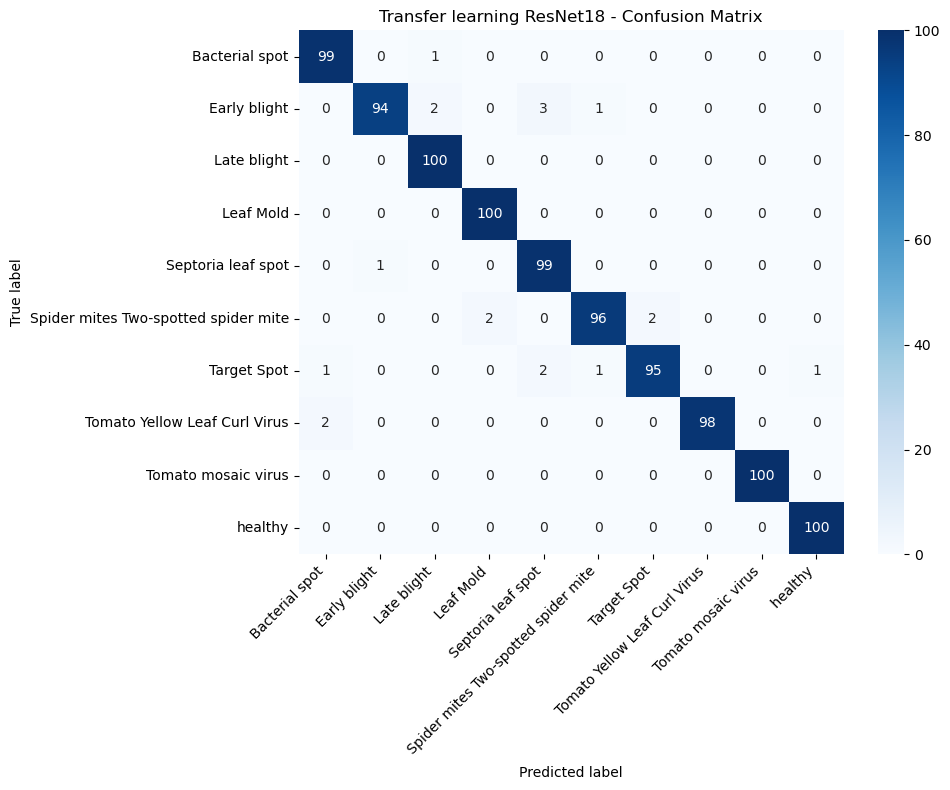

In [64]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[cls.replace("Tomato__", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Transfer learning ResNet18 - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Na osnovu klasifikacionog izveštaja može se zaključiti da model ostvaruje izuzetno visoku tačnost od 98% na test skupu, što ukazuje na veoma uspešno prepoznavanje svih posmatranih klasa bolesti lista paradajza. Vrednosti `precision`, `recall` i `F1-score` za gotovo sve klase kreću se između 0,96 i 1,00, što pokazuje da model postiže veoma uravnotežene i pouzdane rezultate. Posebno se izdvajaju klase `Tomato mosaic virus` i `healthy`, za koje model ostvaruje maksimalan F1-score od 1,00, dok su nešto niže vrednosti zabeležene za klase `Early blight` i `Target Spot`, ali su i one na veoma visokom nivou. Ove rezultate nam takođe potvrđuje i matrica konfuzije, koja je skoro savršena, odnosno sa skoro svim maksimalnim vrednostima na glavnoj dijagonali. 

Dobijeni rezultati potvrđuju da primena transfer learning pristupa sa `ResNet18` arhitekturom omogućava veoma uspešnu klasifikaciju bolesti lista paradajza.